# Squat Form Detection — Autoencoder (Conv1D AE)
**IMU-only · Anomaly detection · Trained on correct squats only**

Detects severe valgus (>15deg) as reconstruction anomaly. Threshold set at 85th percentile of correct squat errors.

## Cell 1 — Imports & Config

In [6]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
BASE      = r'C:\Users\javie\OneDrive - The University of Texas at Austin\Documents\UT - Spring 2026\Human Signals\Final Project'
BASE_FILT = BASE + r'\Filtered_data'

# ── Rates ──────────────────────────────────────────────────
KINE_HZ   = 100
TARGET_HZ = 29
WIN_SEC   = 2.0     # extended from 1.5s — captures more of each rep
OVERLAP   = 0.75    # 75% overlap — more windows from same data
WIN_LEN   = int(WIN_SEC * TARGET_HZ)
STEP      = int(WIN_LEN * (1 - OVERLAP))

# ── IMU channels (model input only) ───────────────────────
imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']

# ── Label map (right knee toes-shank angle) ────────────────
SHEET_LABEL_R = {
    'R < 7'        : 0,
    '10 > R => 7'  : 1,
    '15 > R => 10' : 2,
    'R => 15'      : 3,
}
LABEL_NAMES = ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']
N_CLASSES   = 4

print(f'Window: {WIN_LEN} frames ({WIN_SEC}s @ {TARGET_HZ}Hz)  Step: {STEP} frames')
print(f'IMU channels: {imu_cols}')
print(f'Labels: {LABEL_NAMES}')

Window: 58 frames (2.0s @ 29Hz)  Step: 14 frames
IMU channels: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'pitch', 'roll', 'yaw']
Labels: ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']


## Cell 2 — Data Loading Functions

In [7]:
def load_kine_from_xlsx(xlsx_path):
    """Load frame sequence and time axis from main sheet of bin xlsx."""
    xl   = pd.read_excel(xlsx_path, sheet_name=0)
    data = xl.iloc[3:].copy()
    data.columns = ['frame', 'L_Knee', 'R_Knee']
    data['frame']  = pd.to_numeric(data['frame'],  errors='coerce')
    data['R_Knee'] = pd.to_numeric(data['R_Knee'], errors='coerce')
    data['L_Knee'] = pd.to_numeric(data['L_Knee'], errors='coerce')
    data = data.dropna(subset=['frame']).reset_index(drop=True)
    data['frame']  = data['frame'].astype(int)
    data = data.sort_values('frame').reset_index(drop=True)
    data['time_s'] = (data['frame'] - 1) / KINE_HZ
    return data

def build_frame_labels(xlsx_path):
    """Build {frame: severity_label} dict from bin sheets (right knee only)."""
    xl = pd.read_excel(xlsx_path, sheet_name=None)
    frame_labels = {}
    for sheet_name, label in SHEET_LABEL_R.items():
        sheet_df = xl[sheet_name]
        data = sheet_df.iloc[3:].copy()
        data.columns = ['frame', 'L_Knee', 'R_Knee']
        data['frame'] = pd.to_numeric(data['frame'], errors='coerce')
        frames = data.dropna(subset=['frame'])['frame'].astype(int).values
        for f in frames:
            frame_labels[f] = label
    return frame_labels

def load_watch_imu(fpath):
    """Load SensorLog CSV and return clean IMU DataFrame."""
    df = pd.read_csv(fpath)
    rename = {
        'loggingTime(txt)'               : 'timestamp',
        'motionUserAccelerationX(G)'      : 'ax',
        'motionUserAccelerationY(G)'      : 'ay',
        'motionUserAccelerationZ(G)'      : 'az',
        'motionRotationRateX(rad/s)'      : 'gx',
        'motionRotationRateY(rad/s)'      : 'gy',
        'motionRotationRateZ(rad/s)'      : 'gz',
        'motionPitch(rad)'                : 'pitch',
        'motionRoll(rad)'                 : 'roll',
        'motionYaw(rad)'                  : 'yaw',
    }
    df = df.rename(columns=rename)
    if 'timestamp' in df.columns:
        df = df[df['timestamp'].astype(str).str.startswith('2026', na=False)].reset_index(drop=True)
    df['t']      = pd.to_datetime(df['timestamp'], format='mixed')
    df['time_s'] = (df['t'] - df['t'].iloc[0]).dt.total_seconds()
    for col in imu_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[['time_s'] + imu_cols].dropna().reset_index(drop=True)

def resample_to_hz(df, time_col, value_cols, target_hz):
    """Resample DataFrame to target_hz using linear interpolation."""
    t_orig = df[time_col].values
    t_new  = np.arange(t_orig[0], t_orig[-1], 1.0 / target_hz)
    out = {'time_s': t_new}
    for col in value_cols:
        f = interp1d(t_orig, df[col].values, kind='linear', fill_value='extrapolate')
        out[col] = f(t_new)
    return pd.DataFrame(out)

print('Data loading functions ready.')

Data loading functions ready.


## Cell 3 — Build Windows (IMU-only, MoCap labels)

In [8]:
# ── Trial registry ─────────────────────────────────────────
# Format: (xlsx_path, imu_csv_path, trial_name, subject_id)
# subject_id used for LOSO cross-validation
# NOTE: 6 good trials = 6 different subjects, 2 bad trials = 2 subjects
TRIAL_REGISTRY = [
    (BASE_FILT + r'\Good_1_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_38_29.csv',
     'Good1', 'S01'),
    (BASE_FILT + r'\Good_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_39_59.csv',
     'Good2', 'S02'),
    (BASE_FILT + r'\Good_3_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_41_36.csv',
     'Good3', 'S03'),
    (BASE_FILT + r'\Bad_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_43_42_bad.csv',
     'Bad1',  'S04'),
    (BASE_FILT + r'\Good_4_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_47_16.csv',
     'Good4', 'S05'),
    (BASE_FILT + r'\Good_5_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_48_50.csv',
     'Good5', 'S06'),
    (BASE_FILT + r'\Good_6_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_50_33.csv',
     'Good6', 'S07'),
    (BASE_FILT + r'\Bad_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_57_30_bad2.csv',
     'Bad2',  'S08'),
    # ── Pending: Good7 (MoCap on other computer) ──────────────
    # (BASE_FILT + r'\Good_7_Data_ToesRef_filt.xlsx',
    #  BASE_FILT + r'\stream_Apple_Watch_260414_15_54_40.csv',
    #  'Good7', 'S09'),
]

# ── Alignment note ──────────────────────────────────────────
# The Watch records longer than MoCap (subject walks in/out of capture volume).
# Alignment uses the common time overlap window (t_s → t_e).
# The squat phase is identified by the subject stopping walking — visible as
# a drop in IMU accel magnitude to near-gravity level. The MoCap and Watch
# are trimmed to the same overlapping duration. A future improvement would
# be to detect the walk→squat transition as an explicit sync anchor.

X_all, y_all, subj_all = [], [], []

for (xlsx_path, imu_path, trial_name, subj_id) in TRIAL_REGISTRY:
    frame_labels = build_frame_labels(xlsx_path)
    kine         = load_kine_from_xlsx(xlsx_path)
    kine['label']= kine['frame'].map(frame_labels).fillna(0).astype(int)
    imu          = load_watch_imu(imu_path)

    # Resample kine to TARGET_HZ — label uses nearest-neighbor to preserve integers
    kine_rs = resample_to_hz(kine, 'time_s', ['R_Knee', 'L_Knee'], TARGET_HZ)
    label_interp = interp1d(kine['time_s'].values, kine['label'].values,
                             kind='nearest', fill_value='extrapolate')
    kine_rs['label'] = label_interp(kine_rs['time_s'].values).astype(int).clip(0, 3)

    # Common time window (Watch records longer than MoCap)
    t_s   = max(kine_rs['time_s'].min(), imu['time_s'].min())
    t_e   = min(kine_rs['time_s'].max(), imu['time_s'].max())
    tgrid = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)]['time_s'].values
    km    = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)].reset_index(drop=True)

    for col in imu_cols:
        f_i = interp1d(imu['time_s'].values, imu[col].values,
                       kind='linear', fill_value='extrapolate')
        km[col] = f_i(tgrid)

    # Slide windows over IMU only — max severity label per window
    imu_arr   = km[imu_cols].values
    label_arr = km['label'].values

    windows, labels = [], []
    for i in range(0, len(imu_arr) - WIN_LEN, STEP):
        win       = imu_arr[i : i + WIN_LEN]
        win_label = int(label_arr[i : i + WIN_LEN].max())
        windows.append(win)
        labels.append(win_label)

    X_all.append(np.array(windows))
    y_all.append(np.array(labels))
    subj_all.extend([subj_id] * len(windows))

    dist = Counter(labels)
    print(f'{trial_name:6s} ({subj_id}) -> {len(windows):4d} windows | '
          f'0:{dist.get(0,0):4d}  1:{dist.get(1,0):3d}  '
          f'2:{dist.get(2,0):3d}  3:{dist.get(3,0):3d}')

X       = np.concatenate(X_all)
y       = np.concatenate(y_all)
subjects= np.array(subj_all)
N, T, C = X.shape
print(f'\nTotal: {X.shape} | Label dist: {dict(sorted(Counter(y).items()))}')
print(f'Subjects: {sorted(np.unique(subjects))}')

# ── Normalize — fit on full dataset for LOSO, re-fit per fold inside CV ──────
# Global scaler used for the held-out final evaluation only
scaler_global = StandardScaler()
X_norm_global = scaler_global.fit_transform(X.reshape(N, T*C)).reshape(N, T, C)

# ── Stratified hold-out test set (20%) for final evaluation ──────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_norm_global, y))
scaler  = StandardScaler()
X_train = scaler.fit_transform(
    X[train_idx].reshape(len(train_idx), T*C)).reshape(len(train_idx), T, C)
X_test  = scaler.transform(
    X[test_idx].reshape(len(test_idx), T*C)).reshape(len(test_idx), T, C)
y_train = y[train_idx]
y_test  = y[test_idx]
subj_train = subjects[train_idx]
N_CHANNELS = C

class_weights       = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict   = dict(enumerate(class_weights))

joblib.dump(scaler, 'scaler_imu_only.pkl')

# ── Export scaler params as JSON for Watch deployment ─────────────────────────
import json as json_module
scaler_params = {
    'mean' : scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_names': imu_cols,
    'win_len': WIN_LEN,
    'step'   : STEP,
    'target_hz': TARGET_HZ,
}
with open('scaler_params.json', 'w') as f:
    json_module.dump(scaler_params, f, indent=2)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
for lbl, name in enumerate(LABEL_NAMES):
    tr = np.sum(y_train==lbl); te = np.sum(y_test==lbl)
    print(f'  {lbl} {name:30s}: train={tr:4d}  test={te:3d}')
print(f'Class weights: {[round(float(w),2) for w in class_weights]}')
print('Scaler saved -> scaler_imu_only.pkl')
print('Scaler params saved -> scaler_params.json  (use this in Swift)')

Good1  (S01) ->   49 windows | 0:  17  1: 22  2:  0  3: 10
Good2  (S02) ->   70 windows | 0:  36  1: 13  2:  3  3: 18
Good3  (S03) ->   85 windows | 0:  26  1: 36  2: 12  3: 11
Bad1   (S04) ->   84 windows | 0:  38  1: 20  2:  9  3: 17
Good4  (S05) ->   75 windows | 0:  46  1: 11  2:  1  3: 17
Good5  (S06) ->   71 windows | 0:  44  1:  8  2:  0  3: 19
Good6  (S07) ->   52 windows | 0:   9  1:  8  2:  6  3: 29
Bad2   (S08) ->   70 windows | 0:  25  1: 16  2:  9  3: 20

Total: (556, 58, 9) | Label dist: {np.int64(0): 241, np.int64(1): 134, np.int64(2): 40, np.int64(3): 141}
Subjects: [np.str_('S01'), np.str_('S02'), np.str_('S03'), np.str_('S04'), np.str_('S05'), np.str_('S06'), np.str_('S07'), np.str_('S08')]
Train: 444  |  Test: 112
  0 correct (<7deg)               : train= 192  test= 49
  1 mild (7-10deg)                : train= 107  test= 27
  2 moderate (10-15deg)           : train=  32  test=  8
  3 severe (>15deg)               : train= 113  test= 28
Class weights: [0.58, 1.04, 3

## Cell 4 — Evaluate Helper

In [9]:
def evaluate(model_name, y_true, y_pred, save_prefix=''):
    present = sorted(np.unique(np.concatenate([y_true, y_pred])))
    names   = [LABEL_NAMES[i] for i in present]
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    report = classification_report(y_true, y_pred, labels=present,
                                    target_names=names, zero_division=0)
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, linewidths=0.5)
    plt.title(f'{model_name} -- Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f'cm_{save_prefix}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {fname}')
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'Macro F1: {f1:.3f}')
    return f1

print('evaluate() ready.')

evaluate() ready.


## Cell 5 — Autoencoder Model & Training

Device: cuda
AE training on 192 correct windows (label=0 only)
Held out: 252 valgus windows
  Epoch  50/400 | recon_loss=0.158987
  Epoch 100/400 | recon_loss=0.108874
  Epoch 150/400 | recon_loss=0.087577
  Epoch 200/400 | recon_loss=0.076435
  Epoch 250/400 | recon_loss=0.069010
  Epoch 300/400 | recon_loss=0.065327
  Epoch 350/400 | recon_loss=0.059183
  Epoch 400/400 | recon_loss=0.058827


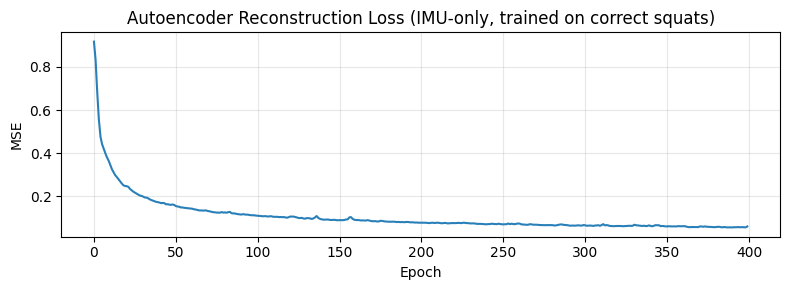

Saved -> ae_imu_only.pt


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

class ConvAE(nn.Module):
    def __init__(self, in_ch, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),    nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, latent_dim, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, 64, kernel_size=4, stride=2, padding=1),         nn.ReLU(),
            nn.Conv1d(64, in_ch, kernel_size=3, padding=1),
        )
    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        if x_hat.shape[-1] != x.shape[-1]:
            x_hat = nn.functional.interpolate(x_hat, size=x.shape[-1])
        return x_hat
    def recon_error(self, x):
        with torch.no_grad():
            return ((x - self.forward(x))**2).mean(dim=(1,2)).cpu().numpy()

# Train on correct-only windows (<7deg confirmed by MoCap)
correct_mask    = (y_train == 0)
X_train_correct = X_train[correct_mask]
print(f'AE training on {len(X_train_correct)} correct windows (label=0 only)')
print(f'Held out: {(~correct_mask).sum()} valgus windows')

ae   = ConvAE(in_ch=N_CHANNELS, latent_dim=32).to(DEVICE)
opt  = torch.optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

Xt     = torch.FloatTensor(X_train_correct).permute(0,2,1)
loader = DataLoader(TensorDataset(Xt), batch_size=16, shuffle=True)

EPOCHS = 400
losses = []
for ep in range(1, EPOCHS+1):
    ae.train()
    ep_loss = sum(
        (lambda xb: (opt.zero_grad(), loss := crit(ae(xb), xb),
                     loss.backward(), opt.step(), loss.item())[4])(xb.to(DEVICE))
        for (xb,) in loader
    ) / len(loader)
    losses.append(ep_loss)
    if ep % 50 == 0:
        print(f'  Epoch {ep:3d}/{EPOCHS} | recon_loss={ep_loss:.6f}')

torch.save(ae.state_dict(), 'ae_imu_only.pt')

plt.figure(figsize=(8,3))
plt.plot(losses, color='#2980B9'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Autoencoder Reconstruction Loss (IMU-only, trained on correct squats)')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('ae_loss.png', dpi=120); plt.show()
print('Saved -> ae_imu_only.pt')

## Cell 6 — Threshold Validation

Deployment threshold (85th pct): 0.1239

  0 correct (<7deg)               : mean=0.0827  detected=15%
  1 mild (7-10deg)                : mean=0.1650  detected=26%
  2 moderate (10-15deg)           : mean=0.1881  detected=18%
  3 severe (>15deg)               : mean=0.4083  detected=44%

Threshold sweep:
  70th | t=0.062 | false_alarm=30%  lbl1=37%  lbl2=45%  lbl3=57%
  75th | t=0.075 | false_alarm=25%  lbl1=31%  lbl2=40%  lbl3=50%
  80th | t=0.095 | false_alarm=20%  lbl1=27%  lbl2=25%  lbl3=48%
  85th | t=0.124 | false_alarm=15%  lbl1=26%  lbl2=18%  lbl3=44%
  90th | t=0.165 | false_alarm=10%  lbl1=22%  lbl2=12%  lbl3=41%
  95th | t=0.255 | false_alarm=5%  lbl1=17%  lbl2=12%  lbl3=38%


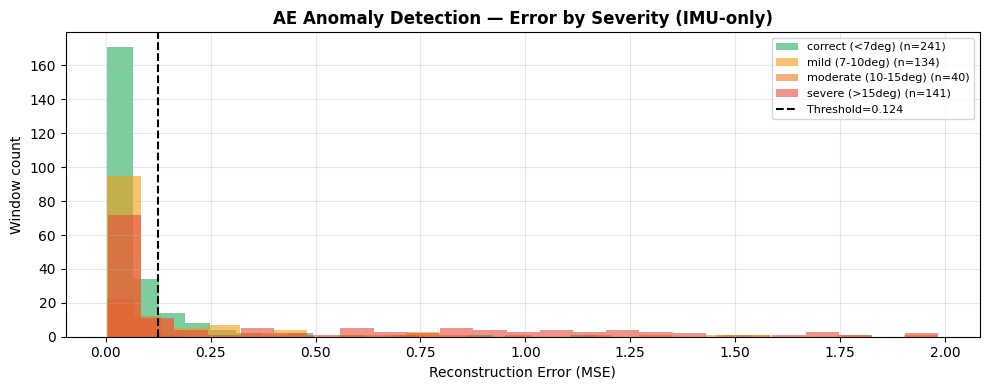

Saved -> ae_threshold.pkl, ae_threshold.png


In [11]:
# ── Anomaly threshold & validation ────────────────────────
ae.eval()

# X_norm_all = all windows normalized with same scaler
X_norm_all = np.concatenate([X_train, X_test])
y_all_norm = np.concatenate([y_train, y_test])

errors_by_label = {0:[], 1:[], 2:[], 3:[]}
for i in range(len(X_norm_all)):
    xt  = torch.FloatTensor(X_norm_all[i:i+1]).permute(0,2,1).to(DEVICE)
    err = ae.recon_error(xt)[0]
    errors_by_label[int(y_all_norm[i])].append(err)
for lbl in range(4):
    errors_by_label[lbl] = np.array(errors_by_label[lbl])

errors_correct   = errors_by_label[0]
DEPLOY_THRESHOLD = float(np.percentile(errors_correct, 85))
joblib.dump({'threshold': DEPLOY_THRESHOLD, 'percentile': 85}, 'ae_threshold.pkl')

print(f'Deployment threshold (85th pct): {DEPLOY_THRESHOLD:.4f}')
print()
colors_lbl = ['#27AE60','#F39C12','#E67E22','#E74C3C']
for lbl, name in enumerate(LABEL_NAMES):
    errs = errors_by_label[lbl]
    if len(errs) == 0: continue
    above = (errs > DEPLOY_THRESHOLD).mean() * 100
    print(f'  {lbl} {name:30s}: mean={errs.mean():.4f}  detected={above:.0f}%')

print()
print('Threshold sweep:')
for pct in [70,75,80,85,90,95]:
    t  = np.percentile(errors_correct, pct)
    fp = (errors_correct > t).mean() * 100
    row = f'  {pct}th | t={t:.3f} | false_alarm={fp:.0f}%'
    for lbl in [1,2,3]:
        if len(errors_by_label[lbl])>0:
            tp = (errors_by_label[lbl]>t).mean()*100
            row += f'  lbl{lbl}={tp:.0f}%'
    print(row)

fig, ax = plt.subplots(figsize=(10,4))
for lbl, name in enumerate(LABEL_NAMES):
    errs = errors_by_label[lbl]
    if len(errs)==0: continue
    ax.hist(errs, bins=25, alpha=0.6, color=colors_lbl[lbl], label=f'{name} (n={len(errs)})')
ax.axvline(DEPLOY_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold={DEPLOY_THRESHOLD:.3f}')
ax.set_xlabel('Reconstruction Error (MSE)'); ax.set_ylabel('Window count')
ax.set_title('AE Anomaly Detection — Error by Severity (IMU-only)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('ae_threshold.png', dpi=130); plt.show()
print('Saved -> ae_threshold.pkl, ae_threshold.png')

## Cell 7 — Per-Channel Error

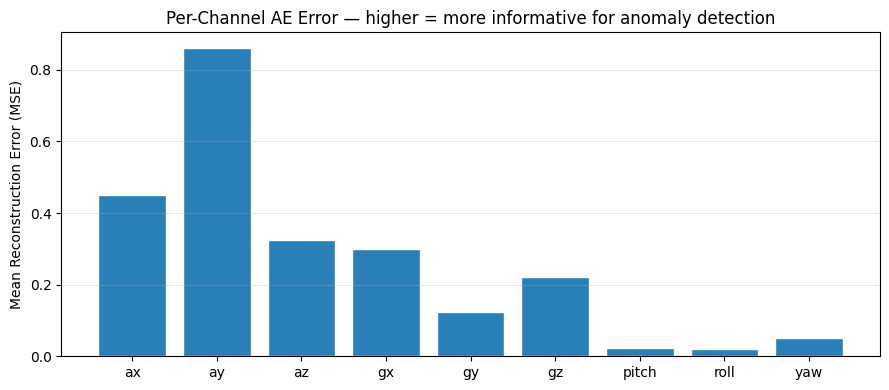

Channels ranked by AE error:
  ay        : 0.861822
  ax        : 0.451146
  az        : 0.324612
  gx        : 0.298410
  gz        : 0.220897
  gy        : 0.124591
  yaw       : 0.051482
  pitch     : 0.023253
  roll      : 0.019855


In [12]:
# ── Per-channel reconstruction error ──────────────────────
ae.eval()
Xt_test = torch.FloatTensor(X_test).permute(0,2,1).to(DEVICE)
with torch.no_grad():
    x_hat  = ae(Xt_test).cpu().numpy()
    x_orig = X_test.transpose(0,2,1)
per_ch = ((x_orig - x_hat)**2).mean(axis=(0,2))

plt.figure(figsize=(9,4))
plt.bar(imu_cols, per_ch, color='#2980B9', edgecolor='white')
plt.ylabel('Mean Reconstruction Error (MSE)')
plt.title('Per-Channel AE Error — higher = more informative for anomaly detection')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('ae_channel_error.png', dpi=130); plt.show()
ranked = sorted(zip(imu_cols, per_ch), key=lambda x: x[1], reverse=True)
print('Channels ranked by AE error:')
for ch, err in ranked:
    print(f'  {ch:<10s}: {err:.6f}')

## Cell 8 — LOSO Threshold Stability

In [13]:
# ── LOSO for AE — threshold stability across subjects ──────
# For AE, LOSO checks if the anomaly threshold generalizes:
# train AE on correct squats from 7 subjects, test threshold on held-out subject
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
loso_thresholds = []
loso_detection  = []

print('LOSO Threshold Stability (8 subjects):')
print('-'*55)

for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups=subjects)):
    subj_te = subjects[te_idx][0]

    # Normalize per fold
    sc_fold   = StandardScaler()
    X_tr_norm = sc_fold.fit_transform(
        X[tr_idx].reshape(len(tr_idx), T*C)).reshape(len(tr_idx), T, C)
    X_te_norm = sc_fold.transform(
        X[te_idx].reshape(len(te_idx), T*C)).reshape(len(te_idx), T, C)

    # Train AE on correct-only from train fold
    correct_mask = (y[tr_idx] == 0)
    X_correct    = X_tr_norm[correct_mask]
    if len(X_correct) < 10:
        print(f'  Fold {fold+1} ({subj_te}): skipped — too few correct windows')
        continue

    ae_fold = ConvAE(in_ch=N_CHANNELS, latent_dim=32).to(DEVICE)
    opt_f   = torch.optim.Adam(ae_fold.parameters(), lr=1e-3)
    crit_f  = nn.MSELoss()
    Xt_f    = torch.FloatTensor(X_correct).permute(0,2,1)
    loader_f = DataLoader(TensorDataset(Xt_f), batch_size=16, shuffle=True)

    for ep in range(150):  # fewer epochs per fold for speed
        ae_fold.train()
        for (xb,) in loader_f:
            xb = xb.to(DEVICE)
            opt_f.zero_grad()
            loss = crit_f(ae_fold(xb), xb)
            loss.backward(); opt_f.step()

    # Compute threshold from train correct errors
    ae_fold.eval()
    Xt_tr_c = torch.FloatTensor(X_correct).permute(0,2,1).to(DEVICE)
    train_errors = ae_fold.recon_error(Xt_tr_c)
    threshold_fold = float(np.percentile(train_errors, 85))
    loso_thresholds.append(threshold_fold)

    # Detection rate on test fold
    Xt_te = torch.FloatTensor(X_te_norm).permute(0,2,1).to(DEVICE)
    te_errors = ae_fold.recon_error(Xt_te)
    severe_mask = (y[te_idx] == 3)
    if severe_mask.sum() > 0:
        detection = (te_errors[severe_mask] > threshold_fold).mean() * 100
        loso_detection.append(detection)
        print(f'  Fold {fold+1} (test={subj_te}): threshold={threshold_fold:.4f} | severe detected={detection:.0f}% (n={severe_mask.sum()})')
    else:
        print(f'  Fold {fold+1} (test={subj_te}): threshold={threshold_fold:.4f} | no severe windows in test')

print('-'*55)
print(f'Threshold stability: {np.mean(loso_thresholds):.4f} ± {np.std(loso_thresholds):.4f}')
if loso_detection:
    print(f'Severe detection LOSO: {np.mean(loso_detection):.1f}% ± {np.std(loso_detection):.1f}%')
print('\nNote: threshold variance tells you how subject-dependent the AE is.')
print('Low std = generalizes well across subjects = safe to deploy with fixed threshold.')

LOSO Threshold Stability (8 subjects):
-------------------------------------------------------
  Fold 1 (test=S01): threshold=0.1803 | severe detected=100% (n=10)
  Fold 2 (test=S02): threshold=0.1611 | severe detected=33% (n=18)
  Fold 3 (test=S03): threshold=0.1181 | severe detected=73% (n=11)
  Fold 4 (test=S04): threshold=0.1714 | severe detected=0% (n=17)
  Fold 5 (test=S05): threshold=0.1708 | severe detected=41% (n=17)
  Fold 6 (test=S06): threshold=0.1740 | severe detected=47% (n=19)
  Fold 7 (test=S07): threshold=0.1572 | severe detected=28% (n=29)
  Fold 8 (test=S08): threshold=0.1850 | severe detected=90% (n=20)
-------------------------------------------------------
Threshold stability: 0.1647 ± 0.0196
Severe detection LOSO: 51.5% ± 31.5%

Note: threshold variance tells you how subject-dependent the AE is.
Low std = generalizes well across subjects = safe to deploy with fixed threshold.
